In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf

In [5]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2024-01-01")

series = data["Close"].dropna()
series = series.squeeze()  # ensure Series

[*********************100%***********************]  1 of 1 completed


In [6]:
train_size = int(len(series) * 0.8)

train = series.iloc[:train_size]
test = series.iloc[train_size:]

In [8]:
# choose your parameters
p, d, q = 1, 1, 1

history = list(train.values)  # safe numeric list
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(p, d, q))
    model_fit = model.fit()

    forecast = model_fit.forecast()[0]
    predictions.append(float(forecast))

    history.append(float(test.iloc[t]))  # update with actual

In [9]:
predictions = pd.Series(predictions, index=test.index)

# Drop first value for naive alignment
test_aligned = test.iloc[1:]
predictions_aligned = predictions.iloc[1:]

In [10]:
naive_predictions = test.shift(1).dropna()
test_aligned = test.iloc[1:]
predictions_aligned = predictions[1:]

In [11]:
rmse_arima = np.sqrt(mean_squared_error(test_aligned, predictions_aligned))
mae_arima = mean_absolute_error(test_aligned, predictions_aligned)

rmse_naive = np.sqrt(mean_squared_error(test_aligned, naive_predictions))
mae_naive = mean_absolute_error(test_aligned, naive_predictions)

print("ARIMA RMSE:", rmse_arima)
print("Naive RMSE:", rmse_naive)

print("ARIMA MAE:", mae_arima)
print("Naive MAE:", mae_naive)

ARIMA RMSE: 2.0902994632741816
Naive RMSE: 2.074041508125843
ARIMA MAE: 1.5786366838014376
Naive MAE: 1.5705466199277052


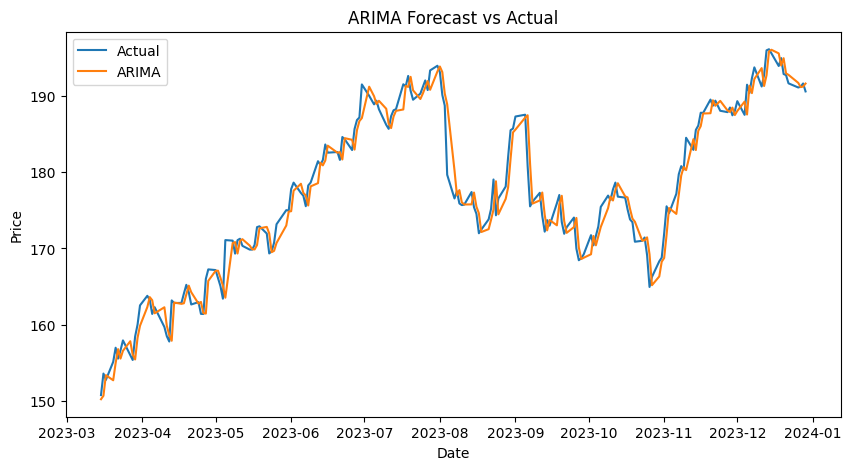

In [12]:
plt.figure(figsize=(10,5))
plt.plot(test_aligned.index, test_aligned, label="Actual")
plt.plot(predictions_aligned.index, predictions_aligned, label="ARIMA")

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

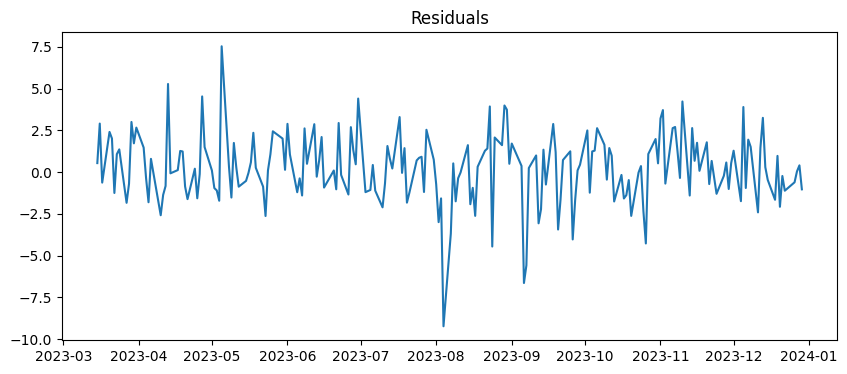

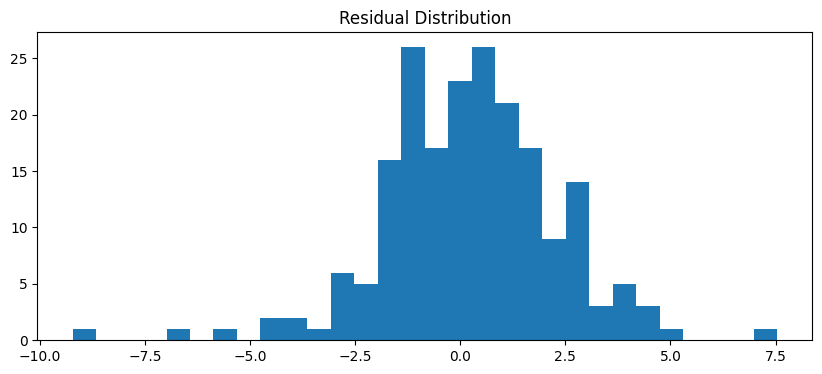

In [15]:
residuals = test_aligned - predictions_aligned

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plt.figure(figsize=(10,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

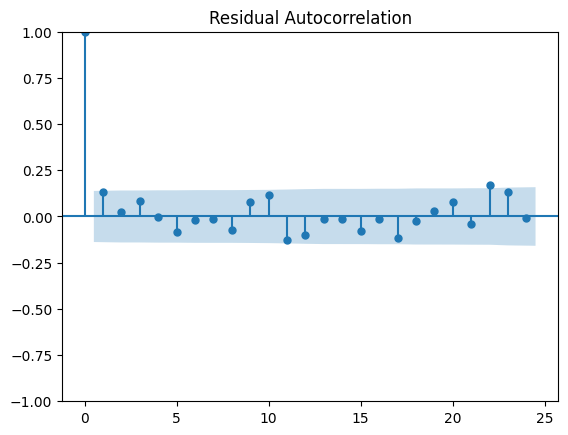

In [16]:
plot_acf(residuals)
plt.title("Residual Autocorrelation")
plt.show()

## Key Insights

- Rolling forecasts simulate real-world deployment of models.
- ARIMA is evaluated against a naive baseline to avoid misleading performance.
- Residual analysis checks whether the model captures all structure.

In financial markets, even sophisticated models often struggle to outperform simple baselines due to market efficiency.